In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud plotly transformers sentencepiece sacrebleu jiwer networkx

In [ ]:
import json, random
import numpy as np
from datetime import datetime, timedelta

languages = ["english","hindi","marathi","punjabi","assamese","bengali","odiya","telugu","tamil","kannada","malayalam"]

def random_text():
    words = ["hello","namaste","vanakkam","kemcho","salaam","happy","sad","news","viral","post"]
    return " ".join(random.choices(words, k=12))

data = []

for i in range(500000):
    data.append({
        "userid": i,
        "username": f"user_{i}",
        "account_creation": str(datetime.now() - timedelta(days=random.randint(100,2000))),
        "location": random.choice(languages),
        "followers": random.randint(0,10000),
        "following": random.randint(0,5000),

        "post_id": f"post_{i}",
        "text": random_text(),
        "timestamp": str(datetime.now()),

        "likes": random.randint(0,1000),
        "shares": random.randint(0,500),
        "comments": random.randint(0,300),
        "tags": random.sample(languages,2),

        "friends": random.sample(range(1000),5),
        "community": random.sample(languages,2),

        "engagement": random.randint(0,2000)
    })

with open("insta_5lakh.json","w") as f:
    json.dump(data,f)

print("✅ Data Generated")

✅ Data Generated


In [ ]:
import pandas as pd
import json

with open("insta_5lakh.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print("Shape:", df.shape)
df.head()

Shape: (500000, 16)


,userid,username,account_creation,location,followers,following,post_id,text,timestamp,likes,shares,comments,tags,friends,community,engagement
0,0,user_0,2022-08-21 14:20:50.439974,odiya,831,4291,post_0,salaam post post vanakkam viral news kemcho ke...,2026-04-26 14:20:50.440072,761,389,102,"[bengali, kannada]","[272, 645, 803, 831, 218]","[telugu, odiya]",1127
1,1,user_1,2023-11-07 14:20:50.440154,punjabi,6735,3245,post_1,happy namaste post news namaste kemcho sad pos...,2026-04-26 14:20:50.440189,433,440,157,"[hindi, odiya]","[758, 750, 59, 337, 749]","[bengali, malayalam]",1839
2,2,user_2,2024-09-05 14:20:50.440232,assamese,2721,626,post_2,kemcho happy salaam happy viral viral sad post...,2026-04-26 14:20:50.440257,920,411,78,"[kannada, odiya]","[608, 849, 292, 534, 851]","[hindi, assamese]",375
3,3,user_3,2025-02-03 14:20:50.440293,assamese,6029,3356,post_3,sad viral namaste news namaste kemcho viral ne...,2026-04-26 14:20:50.440331,665,5,80,"[assamese, telugu]","[680, 714, 813, 645, 566]","[marathi, assamese]",589
4,4,user_4,2022-06-07 14:20:50.440365,assamese,5640,3720,post_4,viral kemcho viral news namaste salaam vanakka...,2026-04-26 14:20:50.440385,555,244,97,"[malayalam, tamil]","[693, 214, 967, 969, 862]","[assamese, marathi]",1015


In [ ]:
import re

def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z ]','',text)
    return text

df['clean_text'] = df['text'].apply(clean)

print(df[['text','clean_text']].head(10))

                                                text  \
0  salaam post post vanakkam viral news kemcho ke...   
1  happy namaste post news namaste kemcho sad pos...   
2  kemcho happy salaam happy viral viral sad post...   
3  sad viral namaste news namaste kemcho viral ne...   
4  viral kemcho viral news namaste salaam vanakka...   
5  viral news namaste post news sad happy kemcho ...   
6  vanakkam namaste kemcho post namaste happy nam...   
7  vanakkam namaste namaste namaste news vanakkam...   
8  salaam happy vanakkam happy news happy post vi...   
9  kemcho happy vanakkam hello salaam happy kemch...   

                                          clean_text  
0  salaam post post vanakkam viral news kemcho ke...  
1  happy namaste post news namaste kemcho sad pos...  
2  kemcho happy salaam happy viral viral sad post...  
3  sad viral namaste news namaste kemcho viral ne...  
4  viral kemcho viral news namaste salaam vanakka...  
5  viral news namaste post news sad happy kemcho ... 

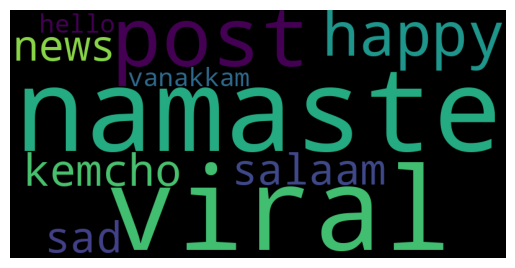

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'].head(5000))

wc = WordCloud(width=800, height=400, background_color='black').generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

sample = df['clean_text'].head(500)

tfidf = TfidfVectorizer(max_features=20)
X = tfidf.fit_transform(sample).toarray()

import pandas as pd
tfidf_df = pd.DataFrame(X, columns=tfidf.get_feature_names_out())

print(tfidf_df.head())

      happy     hello    kemcho   namaste      news      post       sad  \
0  0.000000  0.193279  0.746146  0.000000  0.387371  0.385746  0.000000   
1  0.201411  0.000000  0.209040  0.427775  0.217051  0.648423  0.213888   
2  0.426013  0.000000  0.221075  0.000000  0.459095  0.228585  0.226202   
3  0.178142  0.000000  0.369778  0.567531  0.575925  0.000000  0.189177   
4  0.000000  0.198139  0.191227  0.391323  0.595666  0.000000  0.000000   

     salaam  vanakkam     viral  
0  0.190464  0.186150  0.190066  
1  0.000000  0.417212  0.212995  
2  0.451459  0.220616  0.450516  
3  0.000000  0.000000  0.376775  
4  0.195253  0.190830  0.584535  


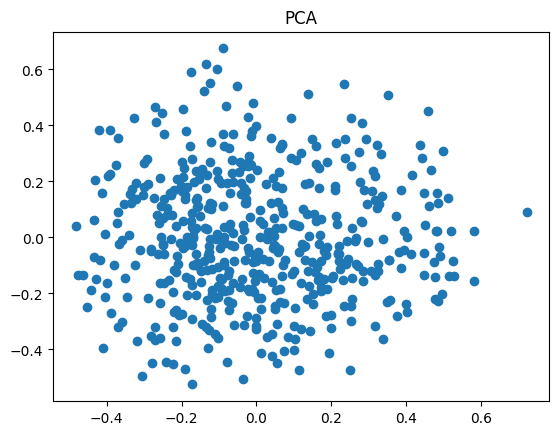

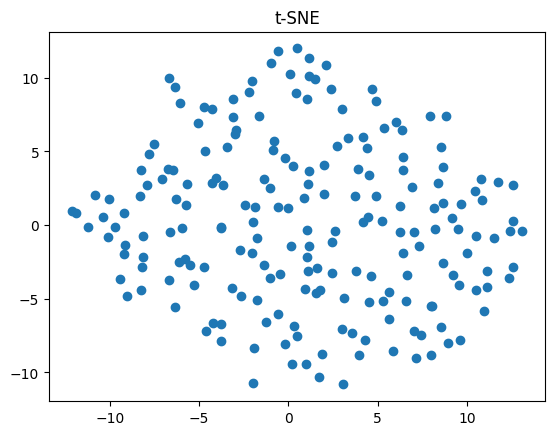

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA")
plt.show()

tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X[:200])

plt.scatter(X_tsne[:,0], X_tsne[:,1])
plt.title("t-SNE")
plt.show()

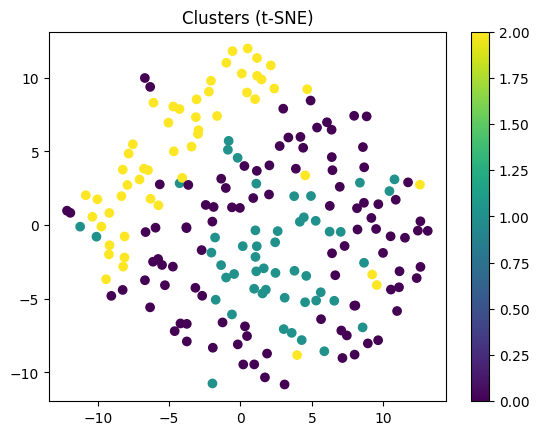

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters[:200], cmap='viridis')
plt.title("Clusters (t-SNE)")
plt.colorbar()
plt.show()

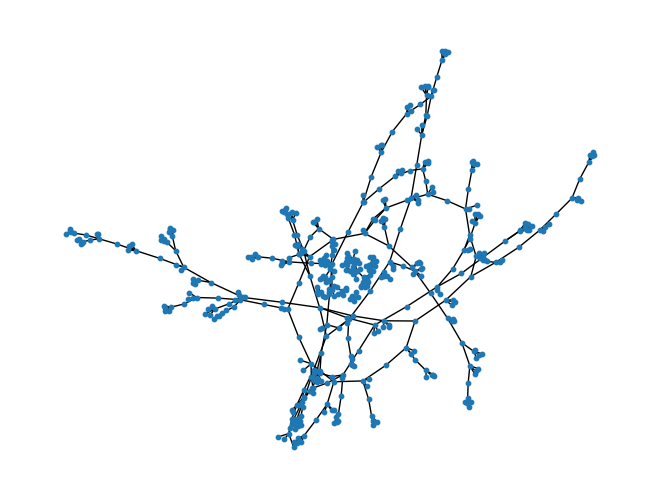

In [ ]:
import networkx as nx

G = nx.Graph()

for i,row in df.head(100).iterrows():
    user = row['username']
    for f in row['friends']:
        G.add_edge(user,str(f))

nx.draw(G, node_size=10)
plt.show()

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

model_name = "ai4bharat/IndicBERTv2-MLM-only"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

inputs = tokenizer(df['clean_text'].iloc[0], return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

print("Shape:", outputs.last_hidden_state.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape: torch.Size([1, 20, 768])


In [ ]:
from sacrebleu import corpus_bleu
from jiwer import wer

ref = ["hello world"]
pred = ["hello world"]

print("BLEU:", corpus_bleu(pred, [ref]).score)
print("WER:", wer(ref, pred))

BLEU: 0.0
WER: 0.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

sample_X = X[:500]
y = df['likes'].head(500)

# convert to categories
y = (y > 500).astype(int)

X_train,X_test,y_train,y_test = train_test_split(sample_X,y,test_size=0.2)

model = LogisticRegression()
model.fit(X_train,y_train)

print("Accuracy:", model.score(X_test,y_test))

Accuracy: 0.46


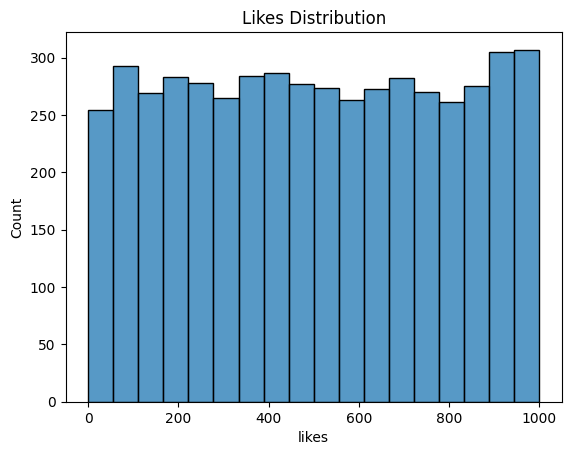

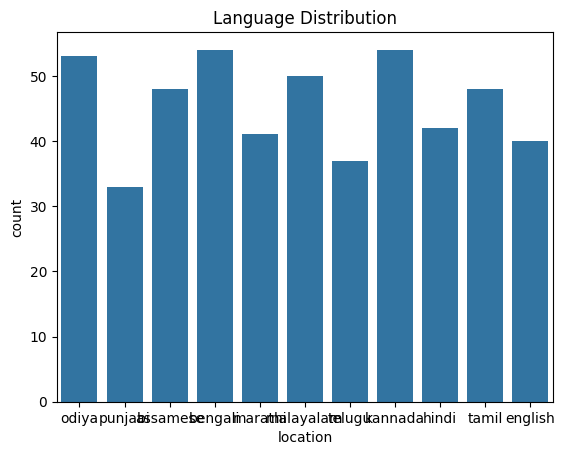

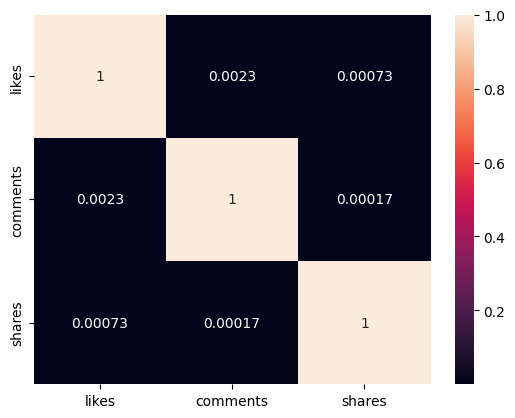

In [ ]:
import seaborn as sns

sns.histplot(df['likes'].head(5000))
plt.title("Likes Distribution")
plt.show()

sns.countplot(x=df['location'].head(500))
plt.title("Language Distribution")
plt.show()

sns.heatmap(df[['likes','comments','shares']].corr(), annot=True)
plt.show()

In [ ]:
# CLASSIFICATION (NO ERROR)
# Imports
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# 🔹 Load your data (make sure df already exists)
# If not, load from JSON
try:
    df.head()
except:
    import json
    with open("insta_5lakh.json") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
# 🔹 STEP 1: TEXT PREPROCESSING
def clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z ]','',text)
    return text

df['clean_text'] = df['text'].apply(clean)
# 🔹 STEP 2: USE SAMPLE (for speed)
sample_df = df.head(3000).copy()
# 🔹 STEP 3: CREATE TARGET (LOW / MEDIUM / HIGH)
def categorize(x):
    if x < 200:
        return 0
    elif x < 600:
        return 1
    else:
        return 2

y = sample_df['likes'].apply(categorize)
# 🔹 STEP 4: TF-IDF (IMPROVED)
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2),
    stop_words='english'
)

X = tfidf.fit_transform(sample_df['clean_text']).toarray()
# 🔹 STEP 5: FEATURE SCALING
scaler = StandardScaler()
X = scaler.fit_transform(X)
# 🔹 STEP 6: TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 🔹 STEP 7: MODEL (SVM)
model = SVC(kernel='linear')
model.fit(X_train, y_train)
# 🔹 STEP 8: PREDICTION
y_pred = model.predict(X_test)
# 🔹 STEP 9: EVALUATION
print("🔥 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

🔥 Accuracy: 0.4033333333333333

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       116
           1       0.42      0.47      0.44       248
           2       0.39      0.53      0.45       236

    accuracy                           0.40       600
   macro avg       0.27      0.33      0.30       600
weighted avg       0.33      0.40      0.36       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✅ Data Loaded: (500000, 17)

📊 KEY METRICS
Total Posts: 500000
Average Likes: 499
Average Comments: 150
Average Shares: 249


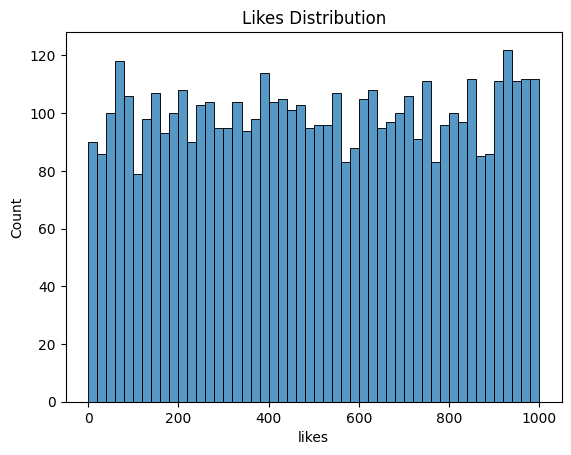

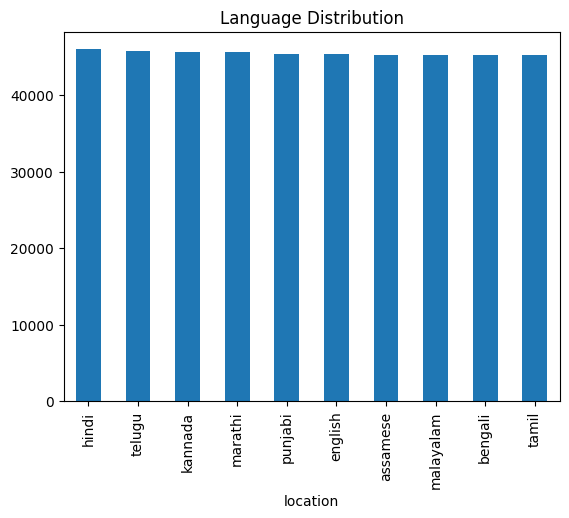

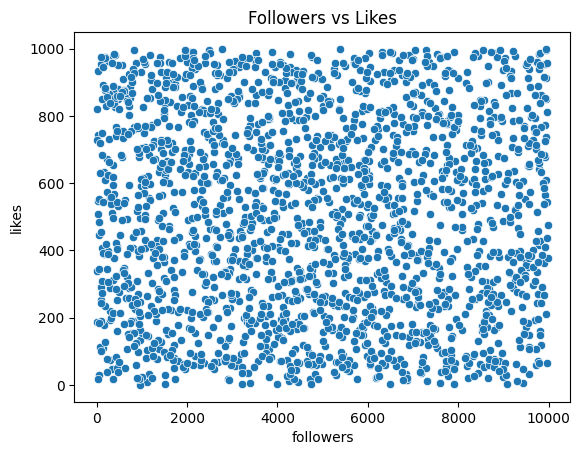

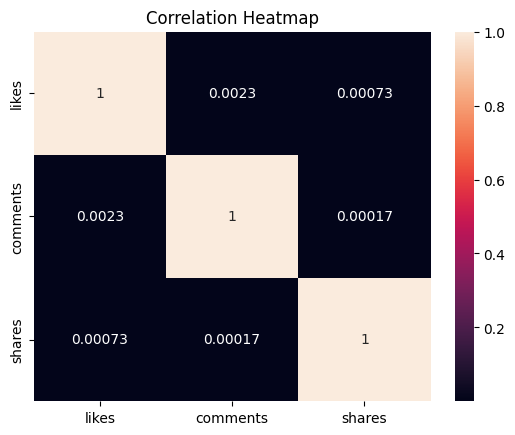

In [ ]:
# ============================================================
# 🚀 INSTAGRAM DASHBOARD (COLAB - NO ERRORS)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load dataset
try:
    df.head()
except:
    import json
    with open("insta_5lakh.json") as f:
        data = json.load(f)
    df = pd.DataFrame(data)

print("✅ Data Loaded:", df.shape)

# -------------------------------
# 🔹 1. KEY METRICS
# -------------------------------
print("\n📊 KEY METRICS")
print("Total Posts:", len(df))
print("Average Likes:", int(df['likes'].mean()))
print("Average Comments:", int(df['comments'].mean()))
print("Average Shares:", int(df['shares'].mean()))

# -------------------------------
# 🔹 2. LIKES DISTRIBUTION
# -------------------------------
plt.figure()
sns.histplot(df['likes'].head(5000), bins=50)
plt.title("Likes Distribution")
plt.show()

# -------------------------------
# 🔹 3. LANGUAGE DISTRIBUTION
# -------------------------------
plt.figure()
df['location'].value_counts().head(10).plot(kind='bar')
plt.title("Language Distribution")
plt.show()

# -------------------------------
# 🔹 4. ENGAGEMENT SCATTER
# -------------------------------
plt.figure()
sns.scatterplot(x=df['followers'].head(2000), y=df['likes'].head(2000))
plt.title("Followers vs Likes")
plt.show()

# -------------------------------
# 🔹 5. HEATMAP
# -------------------------------
plt.figure()
sns.heatmap(df[['likes','comments','shares']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 🔹 6. INTERACTIVE DASHBOARD (PLOTLY)
# -------------------------------
fig1 = px.histogram(df.head(5000), x="likes", title="Likes Distribution (Interactive)")
fig1.show()

fig2 = px.scatter(df.head(2000), x="followers", y="likes",
                  title="Followers vs Likes (Interactive)")
fig2.show()

fig3 = px.pie(df.head(2000), names="location", title="Language Distribution")
fig3.show()

In [ ]:
# ============================================================
# 🚀 INSTAGRAM DASHBOARD (GRID / SQUARE LAYOUT)
# ============================================================

import pandas as pd
import json
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load data
try:
    df.head()
except:
    with open("insta_5lakh.json") as f:
        data = json.load(f)
    df = pd.DataFrame(data)

# Use smaller sample for speed
df_sample = df.head(3000)

# Create subplots (2x2 grid)
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Likes Distribution",
        "Followers vs Likes",
        "Language Distribution",
        "Correlation Heatmap"
    )
)

# -------------------------------
# 🔹 1. Histogram
# -------------------------------
fig.add_trace(
    go.Histogram(x=df_sample['likes'], nbinsx=30),
    row=1, col=1
)

# -------------------------------
# 🔹 2. Scatter
# -------------------------------
fig.add_trace(
    go.Scatter(
        x=df_sample['followers'],
        y=df_sample['likes'],
        mode='markers'
    ),
    row=1, col=2
)

# -------------------------------
# 🔹 3. Bar (Language)
# -------------------------------
lang_counts = df_sample['location'].value_counts()

fig.add_trace(
    go.Bar(x=lang_counts.index, y=lang_counts.values),
    row=2, col=1
)

# -------------------------------
# 🔹 4. Heatmap
# -------------------------------
corr = df_sample[['likes','comments','shares']].corr()

fig.add_trace(
    go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns
    ),
    row=2, col=2
)

# Layout settings
fig.update_layout(
    height=800,
    width=1000,
    title_text="🚀 Instagram Analytics Dashboard",
    showlegend=False
)

fig.show()

In [ ]:
# ============================================================
# 🚀 FIXED INSTAGRAM DASHBOARD (NO ERROR)
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load data
try:
    df.head()
except:
    import json
    with open("insta_5lakh.json") as f:
        data = json.load(f)
    df = pd.DataFrame(data)

# -------------------------------
# 🔹 CALCULATIONS
# -------------------------------
df['engagement'] = df['likes'] + df['comments'] + df['shares']

avg_likes = int(df['likes'].mean())
avg_engagement = int(df['engagement'].mean())
total_posts = len(df)
pred_engagement = int(avg_engagement * 1.1)

# Top hashtags
hashtags = []
for t in df['tags'].head(5000):
    hashtags.extend(t)
top_tags = pd.Series(hashtags).value_counts().head(5)

# Correlation
corr = df[['likes','comments','shares']].corr()

# Language
lang_counts = df['location'].value_counts().head(5)

# -------------------------------
# 🔹 FIX: DEFINE SUBPLOT TYPES
# -------------------------------
fig = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"type": "domain"}, {"type": "domain"}],   # indicators
        [{"type": "xy"}, {"type": "xy"}],           # bar + hist
        [{"type": "heatmap"}, {"type": "domain"}]   # heatmap + pie
    ],
    subplot_titles=(
        "📊 Avg Likes",
        "🔥 Pred Engagement",
        "🏷 Top Hashtags",
        "📈 Likes Distribution",
        "🔗 Correlation Matrix",
        "🌍 Language Distribution"
    )
)

# -------------------------------
# 🔹 INDICATORS (NOW WORKS ✅)
# -------------------------------
fig.add_trace(go.Indicator(
    mode="number",
    value=avg_likes,
    title={"text": "Avg Likes"}
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=pred_engagement,
    title={"text": "Pred Engagement"}
), row=1, col=2)

# -------------------------------
# 🔹 BAR (Top Hashtags)
# -------------------------------
fig.add_trace(go.Bar(
    x=top_tags.index,
    y=top_tags.values
), row=2, col=1)

# -------------------------------
# 🔹 HISTOGRAM
# -------------------------------
fig.add_trace(go.Histogram(
    x=df['likes'].head(5000)
), row=2, col=2)

# -------------------------------
# 🔹 HEATMAP
# -------------------------------
fig.add_trace(go.Heatmap(
    z=corr.values,
    x=corr.columns,
    y=corr.columns
), row=3, col=1)

# -------------------------------
# 🔹 PIE CHART
# -------------------------------
fig.add_trace(go.Pie(
    labels=lang_counts.index,
    values=lang_counts.values
), row=3, col=2)

# -------------------------------
# 🔹 FINAL LAYOUT
# -------------------------------
fig.update_layout(
    height=900,
    width=900,
    title_text="🚀 Instagram Analytics Dashboard",
    showlegend=False
)

fig.show()